Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

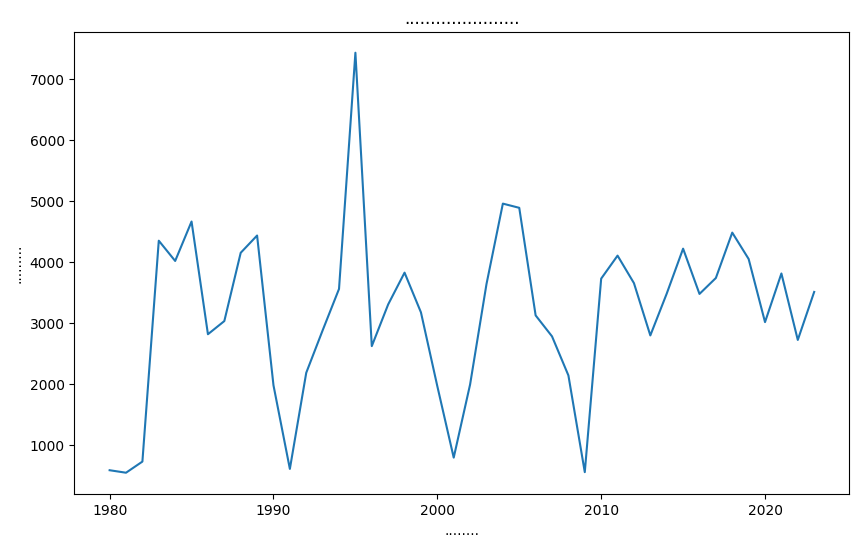

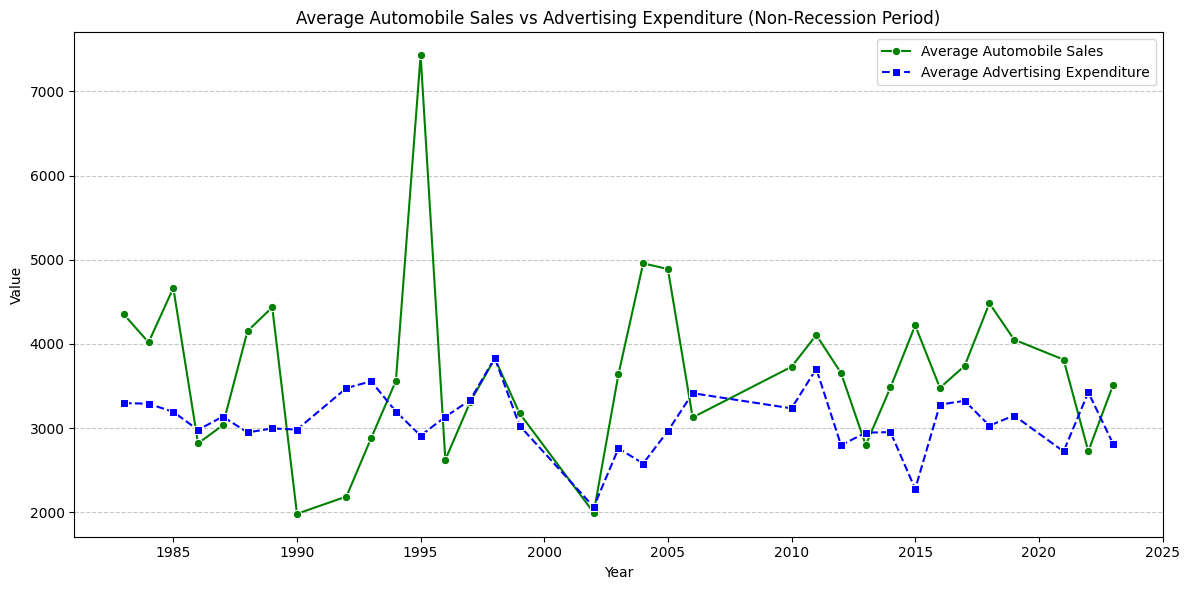

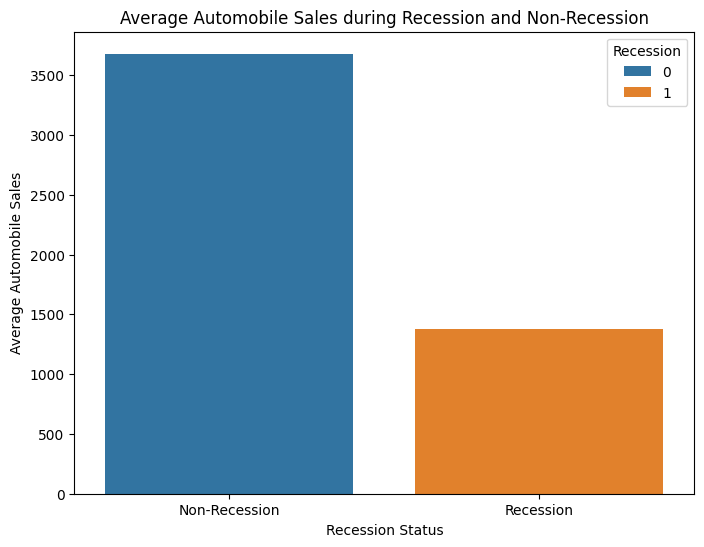

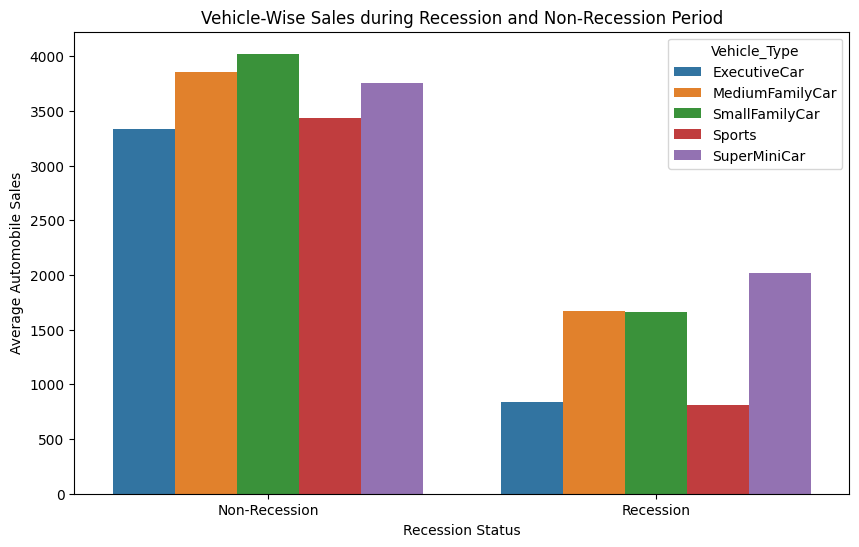

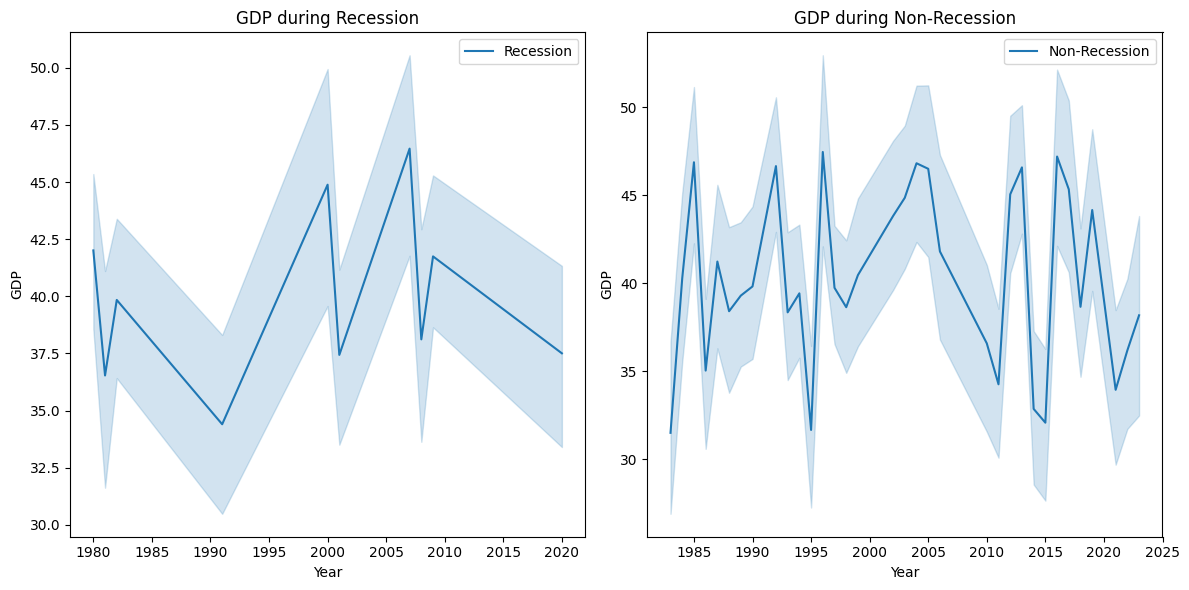

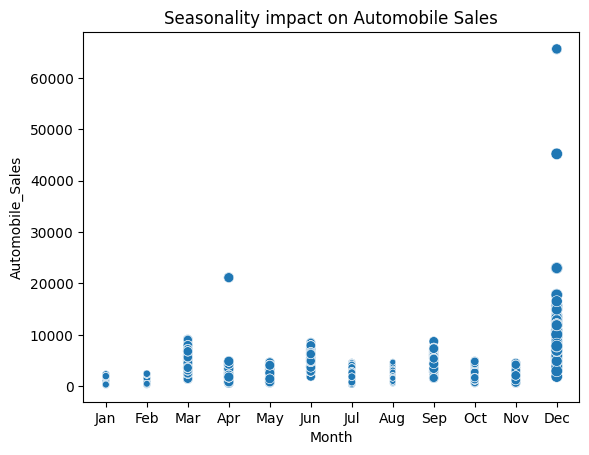

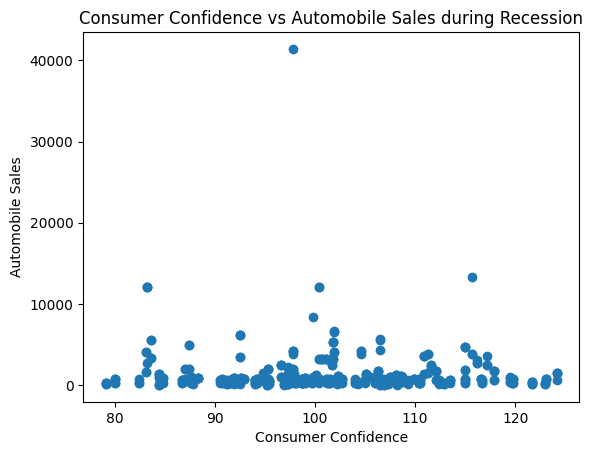

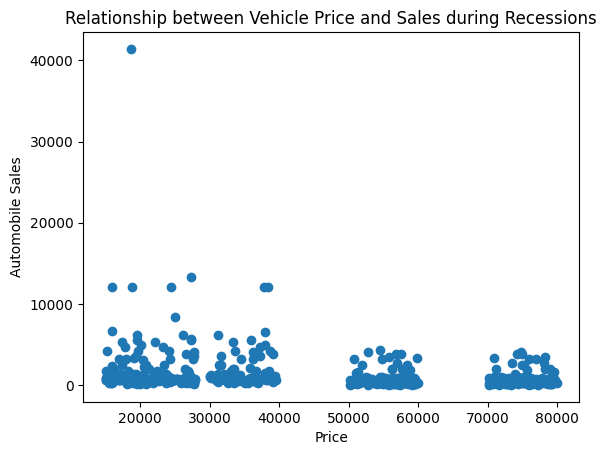

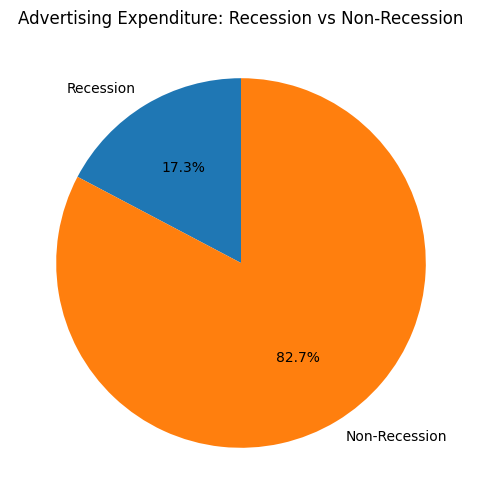

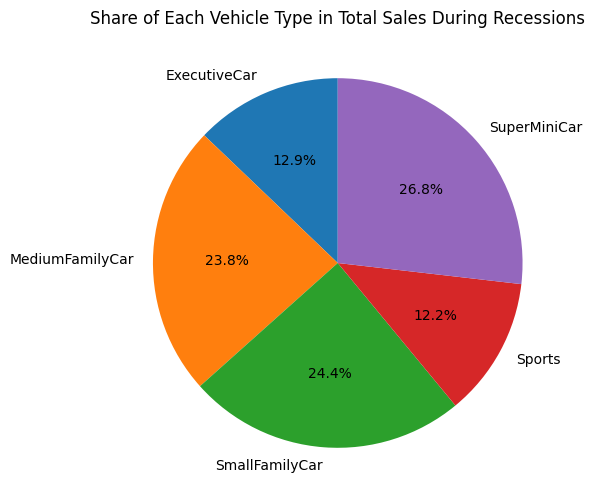

ValueError: Could not interpret value `Unemployment_Rate` for `x`. An entry with this name does not appear in `data`.

<Figure size 1600x600 with 0 Axes>

In [18]:

import requests
import io
import pandas as pd

# URL of the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

# Fetch the data from the URL
response = requests.get(URL)

# Raise an error if the request failed
response.raise_for_status()

# Convert the response content into a readable format for pandas
csv_content = io.StringIO(response.text)

# Read the CSV data into a pandas dataframe
df = pd.read_csv(csv_content)

# Print confirmation
print('Data downloaded and read into a dataframe!')
# Optional: Show the first few rows of the dataframe
print(df.head())
df.describe()
df.columns

#create data for plotting
import matplotlib.pyplot as plt
df_line = df.groupby(df['Year'])['Automobile_Sales'].mean()
#create figure 
plt.figure(figsize=(10, 6))
df_line.plot(kind = 'line')
plt.xlabel('........')
plt.ylabel('.........')
plt.title('......................')
plt.show()

#1.2
# Assuming 'df' is your dataset
import matplotlib.pyplot as plt
import seaborn as sns
df_non_rec = df[df['Recession'] == 0]

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)

# Create line plots for average sales and advertising expenditure over the years
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends, x='Year', y='Avg_Sales', marker='o', linestyle='-',
             color='green', label='Average Automobile Sales')
sns.lineplot(data=df_trends, x='Year', y='Avg_Ad_Spend', marker='s', linestyle='--',
             color='blue', label='Average Advertising Expenditure')

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Average Automobile Sales vs Advertising Expenditure (Non-Recession Period)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

#1.3
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

# Create the bar chart using seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession', data=new_df)
plt.xlabel('Recession Status')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.show()

grouped_df = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

# Create the grouped bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=grouped_df)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Recession Status')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')
plt.show()


#1.4
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

plt.figure(figsize=(12, 6))

#subplot 1
plt.subplot(1, 2, 1)
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.title('GDP during Recession')
plt.legend()

#subplot 2
plt.subplot(1, 2, 2)
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-Recession')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.title('GDP during Non-Recession')
plt.legend()

plt.tight_layout()
plt.show()


#1.5
non_rec_data = df[df['Recession'] == 0]

size = non_rec_data['Seasonality_Weight'] #for bubble effect

sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales', size=size, legend=False)

#you can further include hue='Seasonality_Weight', legend=False)

plt.xlabel('Month')
plt.ylabel('Automobile_Sales')
plt.title('Seasonality impact on Automobile Sales')
plt.show()


#1.6
#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'])

plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence vs Automobile Sales during Recession')
plt.show()

#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'])

plt.xlabel('Price')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Vehicle Price and Sales during Recessions')
plt.show()


#1.7
# Filter the data
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

# Calculate the total advertising expenditure for both periods
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

# Create a pie chart for the advertising expenditure
plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Advertising Expenditure: Recession vs Non-Recession')
plt.show()


#1.8
# Filter the data
Rdata = df[df['Recession'] == 1]

# Calculate the sales volume by vehicle type during recessions
VTexpenditure = Rdata.groupby('Vehicle_Type')['Automobile_Sales'].sum()

# Create a pie chart for the share of each vehicle type in total expenditure during recessions
plt.figure(figsize=(8, 6))

labels = VTexpenditure.index
sizes = VTexpenditure.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Share of Each Vehicle Type in Total Sales During Recessions')
plt.show()


#1.9
# Assuming 'df' is your dataset
df_rec = df[df['Recession'] == 1]

# Set figure size
plt.figure(figsize=(16, 6))

# Create line plot showing effect of unemployment rate on automobile sales by vehicle type
sns.lineplot(
    data=df_rec,
    x='Unemployment_Rate',
    y='Automobile_Sales',
    hue='Vehicle_Type',
    marker='o'
)

# Customize labels, legend, and title
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales During Recession')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')

# Show plot
plt.tight_layout()
plt.show()